# Chapter 2: Data and Sampling Distributions

## Introduction

This chapter explores data and sampling distributions. It explains how samples are selected from a population and how sampling methods affect statistical estimates.

The chapter introduces sampling distributions, the Central Limit Theorem, standard error, bootstrapping, confidence intervals, and several probability distributions.

## Learning Objectives

After completing this chapter, students should be able to:

* Understand random sampling and sample bias.
* Explain sampling distributions and the Central Limit Theorem.
* Calculate and interpret standard errors.
* Understand bootstrapping and confidence intervals.
* Explore statistical distributions using Python.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Random Sampling and Sample Bias

A population is the complete set of observations being studied, while a sample is a subset selected from that population.

Random sampling gives each available member of the population an equal chance of selection at each draw. Sampling can be performed with replacement or without replacement.

Sample bias occurs when a sample does not adequately represent the population. A representative sample is important for producing reliable statistical estimates.


In [2]:
population = np.arange(1, 1001)

random_sample = np.random.choice(
    population, size=100, replace=False
)
biased_sample = population[:100]

print("Population mean:", np.mean(population))
print("Random sample mean:", np.mean(random_sample))
print("Biased sample mean:", np.mean(biased_sample))

Population mean: 500.5
Random sample mean: 489.78
Biased sample mean: 50.5


## 2. Selection Bias

Selection bias occurs when the method used to select observations systematically excludes or overrepresents certain members of the population.

For example, an online survey about internet usage may underrepresent people who rarely use the internet.

Selection bias can affect the validity of conclusions, even when the sample contains many observations.


In [3]:
# Simulated population with two groups
population_groups = pd.DataFrame({
    "Group": ["A"] * 800 + ["B"] * 200
})

print("Population proportions:")
print(
    population_groups["Group"]
    .value_counts(normalize=True)
)

# Biased sample that overrepresents Group B
biased_selection = pd.DataFrame({
    "Group": ["A"] * 20 + ["B"] * 80
})

print("\nBiased sample proportions:")
print(
    biased_selection["Group"]
    .value_counts(normalize=True)
)

Population proportions:
Group
A    0.8
B    0.2
Name: proportion, dtype: float64

Biased sample proportions:
Group
B    0.8
A    0.2
Name: proportion, dtype: float64


## 3. Sampling Distribution of a Statistic

A sampling distribution is the probability distribution of a statistic calculated from repeated samples of the same size drawn from a population.

For example, repeatedly drawing samples and calculating their means produces a sampling distribution of the sample mean.

This distribution helps us understand how much a statistic varies from one sample to another.


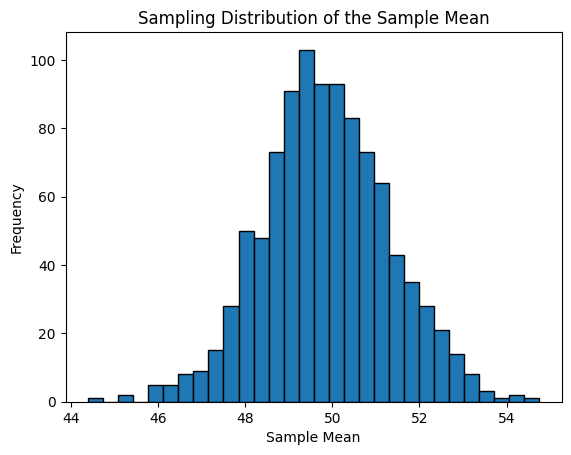

Mean of sample means: 49.85228524305824


In [4]:
population_data = np.random.normal(
    loc=50, scale=10, size=10000
)

sample_means = []

for _ in range(1000):
    sample = np.random.choice(
        population_data, size=50, replace=True
    )
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=30, edgecolor="black")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

print("Mean of sample means:", np.mean(sample_means))

## 4. Central Limit Theorem

The Central Limit Theorem (CLT) states that, under appropriate conditions, the sampling distribution of the sample mean approaches a normal distribution as the sample size becomes sufficiently large.

This can occur even when the original population distribution is not normal, provided the observations satisfy the relevant assumptions, such as independence and finite variance.

The CLT is important because it helps explain why normal-based statistical methods are useful for many sample statistics.


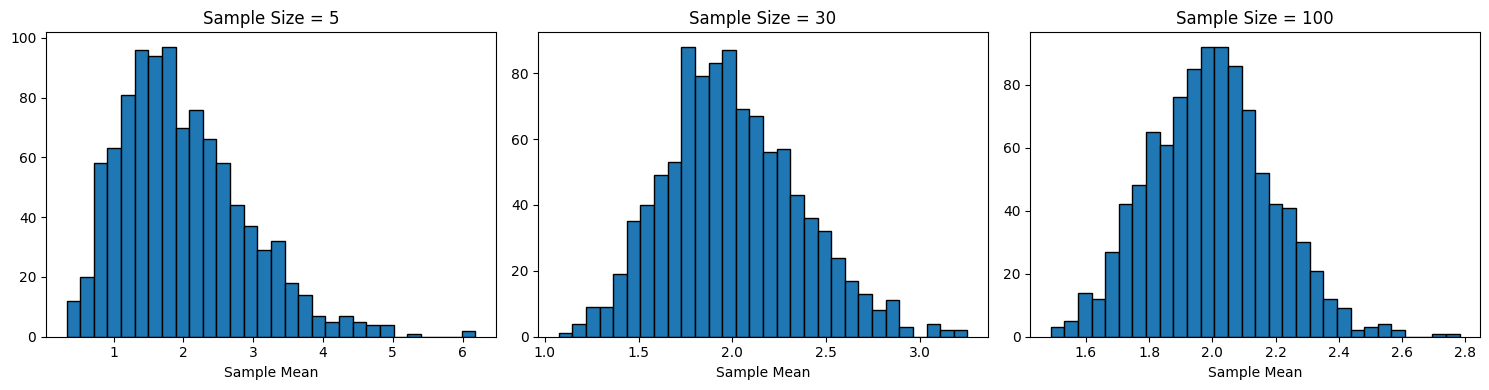

In [5]:
# Use a strongly right-skewed population
population_data = np.random.exponential(
    scale=2, size=100000
)

sample_sizes = [5, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    means = [
        np.mean(np.random.choice(
            population_data, size=n, replace=True
        ))
        for _ in range(1000)
    ]

    ax.hist(means, bins=30, edgecolor="black")
    ax.set_title(f"Sample Size = {n}")
    ax.set_xlabel("Sample Mean")

plt.tight_layout()
plt.show()

## 5. Standard Error

The standard error (SE) measures the variability of a sample statistic across repeated samples.

For the sample mean, when observations are independent and identically distributed with a finite variance, the standard error is estimated by:

SE = s / √n

where s is the sample standard deviation and n is the sample size.

A larger sample generally produces a smaller standard error for the sample mean.


In [6]:
data = np.random.normal(
    loc=100, scale=15, size=500
)

for n in [25, 100, 400]:
    sample = np.random.choice(
        data, size=n, replace=False
    )
    standard_error = np.std(sample, ddof=1) / np.sqrt(n)

    print(
        f"Sample size: {n}, "
        f"Standard error: {standard_error:.3f}"
    )

Sample size: 25, Standard error: 2.913
Sample size: 100, Standard error: 1.418
Sample size: 400, Standard error: 0.719


## 6. The Bootstrap

Bootstrapping is a resampling method used to estimate the variability of a statistic.

It repeatedly draws samples with replacement from the observed sample. A statistic, such as the mean or median, is calculated for each bootstrap sample.

The resulting bootstrap distribution can help estimate standard errors and confidence intervals without relying entirely on theoretical distribution assumptions.


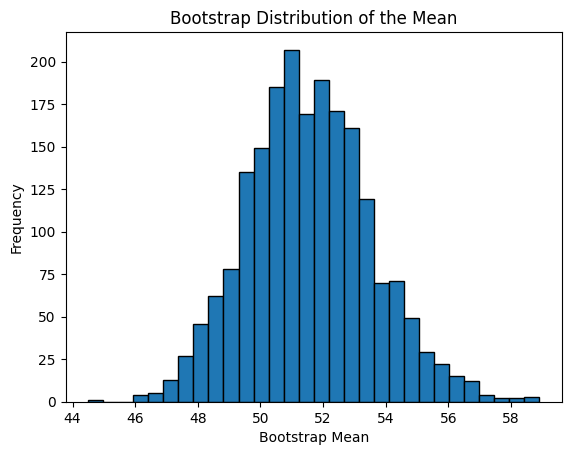

Original sample mean: 51.5
Bootstrap standard error: 1.983058157828122


In [7]:
data = np.array([
    42, 45, 47, 49, 50, 51, 53, 55, 58, 65
])

bootstrap_means = []

for _ in range(2000):
    bootstrap_sample = np.random.choice(
        data, size=len(data), replace=True
    )
    bootstrap_means.append(np.mean(bootstrap_sample))

plt.hist(bootstrap_means, bins=30, edgecolor="black")
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.show()

print("Original sample mean:", np.mean(data))
print(
    "Bootstrap standard error:",
    np.std(bootstrap_means, ddof=1)
)

## 7. Confidence Intervals

A confidence interval provides a range of plausible values for a population parameter based on sample data.

A 95% confidence interval procedure is designed so that, over repeated sampling under its assumptions, approximately 95% of the intervals constructed by that procedure contain the true parameter.

For a sample mean, a t-based confidence interval can be used when the population standard deviation is unknown and the relevant assumptions are reasonable.


In [8]:
data = np.array([
    72, 75, 78, 80, 82, 85, 77, 79, 81, 83,
    74, 76, 88, 84, 80, 79, 82, 86, 73, 81
])

n = len(data)
mean = np.mean(data)
standard_error = stats.sem(data)

ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean,
    scale=standard_error
)

print("Sample mean:", mean)
print("95% confidence interval:", (ci_low, ci_high))

Sample mean: 79.75
95% confidence interval: (np.float64(77.70221705214124), np.float64(81.79778294785876))


## 8. Normal Distribution

The normal distribution is a continuous, symmetric, bell-shaped probability distribution characterized by its mean and standard deviation.

The standard normal distribution has a mean of 0 and a standard deviation of 1.

A z-score expresses how many standard deviations an observation lies above or below the mean. A Q-Q plot can be used to compare sample quantiles with theoretical normal quantiles.


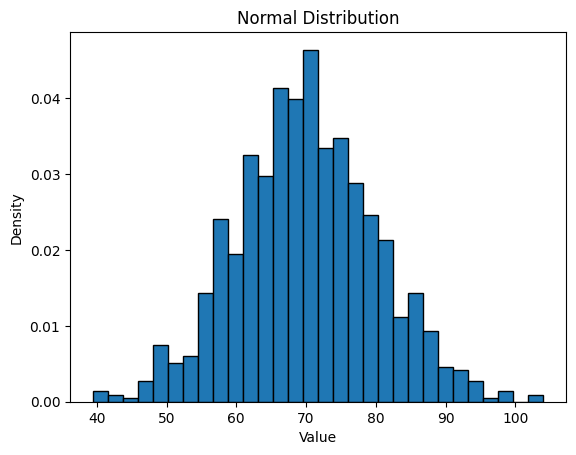

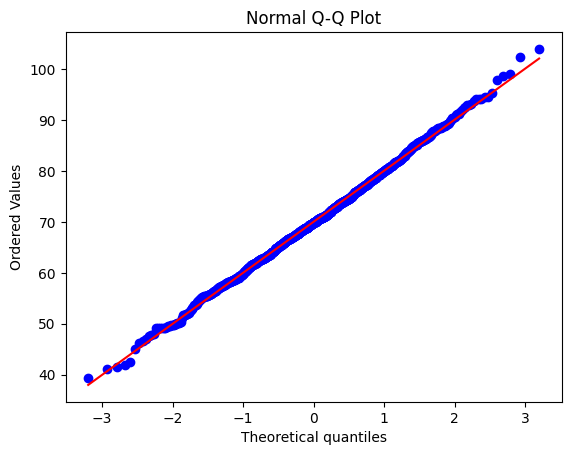

Mean: 70.06222479098122
Standard deviation: 10.019931495288683
First five z-scores: [ 0.78360773 -0.24457755 -1.64309535  1.62554642 -0.27805241]


In [9]:
data = np.random.normal(
    loc=70, scale=10, size=1000
)

z_scores = stats.zscore(data)

plt.hist(data, bins=30, density=True, edgecolor="black")
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

stats.probplot(data, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

print("Mean:", np.mean(data))
print("Standard deviation:", np.std(data, ddof=1))
print("First five z-scores:", z_scores[:5])

## 9. Student's t-Distribution

Student's t-distribution is a symmetric probability distribution with heavier tails than the standard normal distribution.

It is commonly used to estimate a population mean when the population standard deviation is unknown, particularly for smaller samples under appropriate assumptions.

As the degrees of freedom increase, the t-distribution approaches the standard normal distribution.


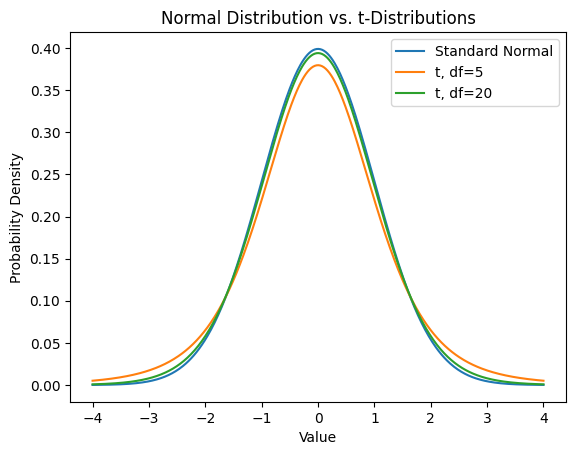

In [10]:
x = np.linspace(-4, 4, 500)

plt.plot(x, stats.norm.pdf(x), label="Standard Normal")
plt.plot(x, stats.t.pdf(x, df=5), label="t, df=5")
plt.plot(x, stats.t.pdf(x, df=20), label="t, df=20")

plt.title("Normal Distribution vs. t-Distributions")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

## 10. Binomial Distribution

The binomial distribution describes the number of successes in a fixed number of independent trials, each with the same probability of success.

Its parameters are n, the number of trials, and p, the probability of success in each trial.

Examples include counting the number of successful transactions or the number of heads obtained in repeated coin tosses.


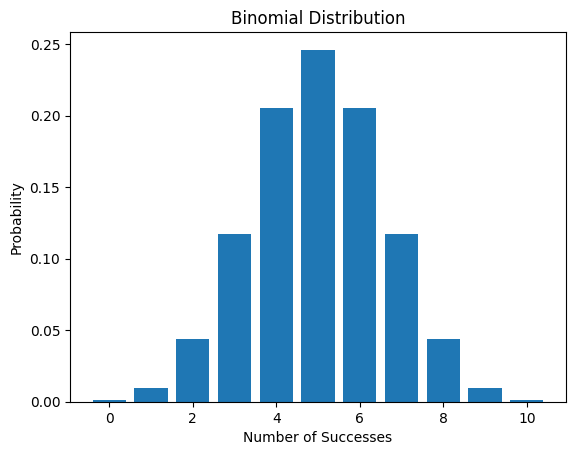

Expected number of successes: 5.0
Variance: 2.5


In [11]:
n = 10
p = 0.5

x = np.arange(0, n + 1)
probabilities = stats.binom.pmf(x, n, p)

plt.bar(x, probabilities)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.show()

print("Expected number of successes:", stats.binom.mean(n, p))
print("Variance:", stats.binom.var(n, p))

## 11. Chi-Square Distribution

The chi-square distribution is a continuous probability distribution defined by its degrees of freedom.

It is used in several statistical procedures, including tests of independence for categorical variables and inference about population variance under appropriate assumptions.

The distribution is nonnegative and generally right-skewed, especially when the degrees of freedom are small.


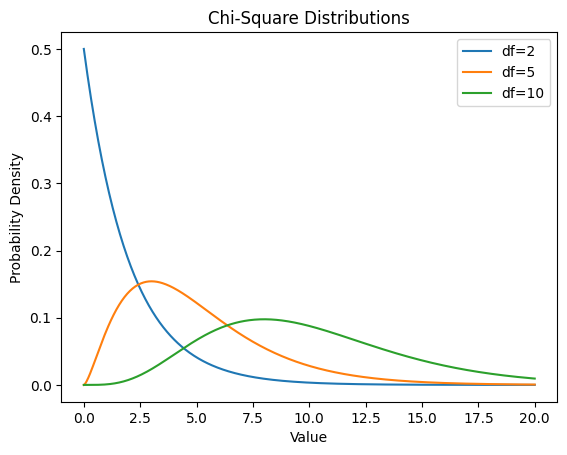

In [12]:
x = np.linspace(0, 20, 500)

for df in [2, 5, 10]:
    plt.plot(x, stats.chi2.pdf(x, df), label=f"df={df}")

plt.title("Chi-Square Distributions")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

## 12. F-Distribution

The F-distribution is a continuous probability distribution determined by two degrees of freedom.

It is used in statistical procedures such as analysis of variance (ANOVA) and tests comparing variance-related quantities.

The F-distribution is nonnegative and typically right-skewed.


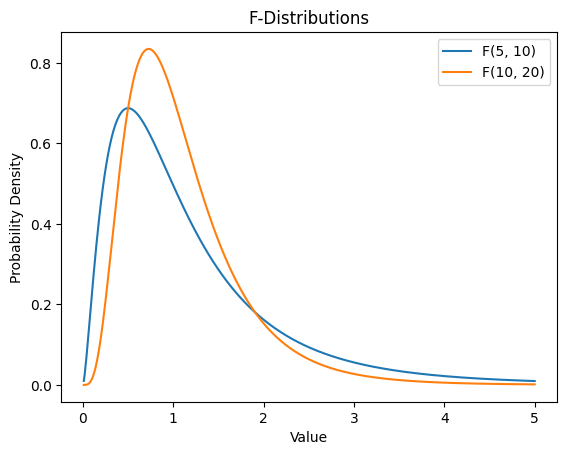

In [13]:
x = np.linspace(0.01, 5, 500)

plt.plot(x, stats.f.pdf(x, 5, 10), label="F(5, 10)")
plt.plot(x, stats.f.pdf(x, 10, 20), label="F(10, 20)")

plt.title("F-Distributions")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

## 13. Poisson and Related Distributions

### Poisson Distribution

The Poisson distribution models the number of events occurring in a fixed interval when events occur independently at a constant average rate under the model's assumptions.

### Exponential Distribution

The exponential distribution models waiting times between events in a Poisson process. Its rate parameter determines the average event rate.

### Weibull Distribution

The Weibull distribution is a flexible distribution used in reliability analysis and survival modeling. Its shape and scale parameters allow it to represent different patterns of failure times.


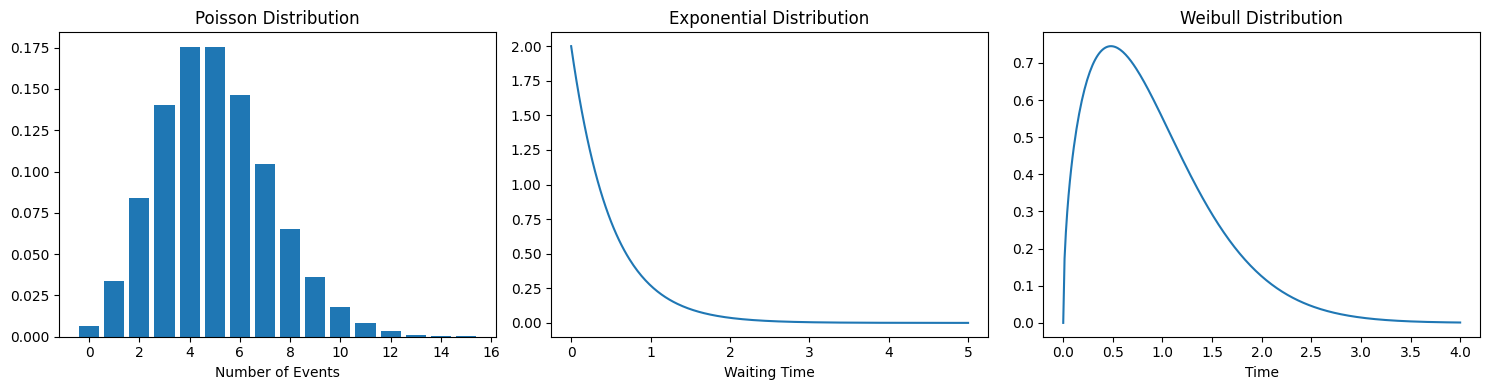

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Poisson distribution
x_poisson = np.arange(0, 16)
axes[0].bar(
    x_poisson,
    stats.poisson.pmf(x_poisson, mu=5)
)
axes[0].set_title("Poisson Distribution")
axes[0].set_xlabel("Number of Events")

# Exponential distribution
x_exp = np.linspace(0, 5, 300)
axes[1].plot(
    x_exp,
    stats.expon.pdf(x_exp, scale=1/2)
)
axes[1].set_title("Exponential Distribution")
axes[1].set_xlabel("Waiting Time")

# Weibull distribution
x_weibull = np.linspace(0, 4, 300)
axes[2].plot(
    x_weibull,
    stats.weibull_min.pdf(x_weibull, c=1.5, scale=1)
)
axes[2].set_title("Weibull Distribution")
axes[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

## 14. Summary

This chapter introduced data and sampling distributions and their roles in statistical analysis.

Key concepts include:

* Random sampling and sample bias.
* Selection bias and representativeness.
* Sampling distributions and the Central Limit Theorem.
* Standard error, bootstrapping, and confidence intervals.
* Normal and Student's t-distributions.
* Binomial, chi-square, and F-distributions.
* Poisson, exponential, and Weibull distributions.

These concepts help analysts understand sampling variability, quantify uncertainty, and select appropriate statistical methods for different types of data.
